# 🛋️ E-commerce Furniture Sales Analysis – Python Project

## Step 1: Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')


## Step 2: Load the Dataset

In [2]:

# Load dataset (make sure the file is in the same folder)
df = pd.read_csv("ecommerce_furniture_dataset_2024 (1).csv")

print("🔹 First 5 rows of data:")
print(df.head())

print("\n🔹 Dataset Information:")
print(df.info())

print("\nShape of data:", df.shape)


🔹 First 5 rows of data:
                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           $30   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...          $116  $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...         $78.4   $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...           $89  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

   sold        tagText  
0   600  Free shipping  
1     9  Free shipping  
2     7  Free shipping  
3     2  Free shipping  
4     1  Free shipping  

🔹 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  498 non-null    object
 2   price          2000 non-null   object
 3   s

## Step 3: Data Cleaning

In [3]:

print("\nMissing values:\n", df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

df.drop_duplicates(inplace=True)

print("\nAfter cleaning, shape:", df.shape)



Missing values:
 productTitle        0
originalPrice    1502
price               0
sold                0
tagText             3
dtype: int64

After cleaning, shape: (1907, 5)


## Step 4: Basic Data Exploration

In [4]:

print("\nSummary Statistics:\n", df.describe())
print("\nUnique values per column:\n", df.nunique())



Summary Statistics:
                sold
count   1907.000000
mean      29.712113
std      346.214793
min        0.000000
25%        1.000000
50%        3.000000
75%       10.000000
max    10000.000000

Unique values per column:
 productTitle     1793
originalPrice     463
price            1802
sold              116
tagText           100
dtype: int64


## Step 5: Exploratory Data Analysis (EDA)

/tmp/ipython-input-2700917013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='productTitle', y='sold', data=df.head(10), palette='Blues')
/tmp/ipython-input-2700917013.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.9]) # Further adjust layout to prevent overlap


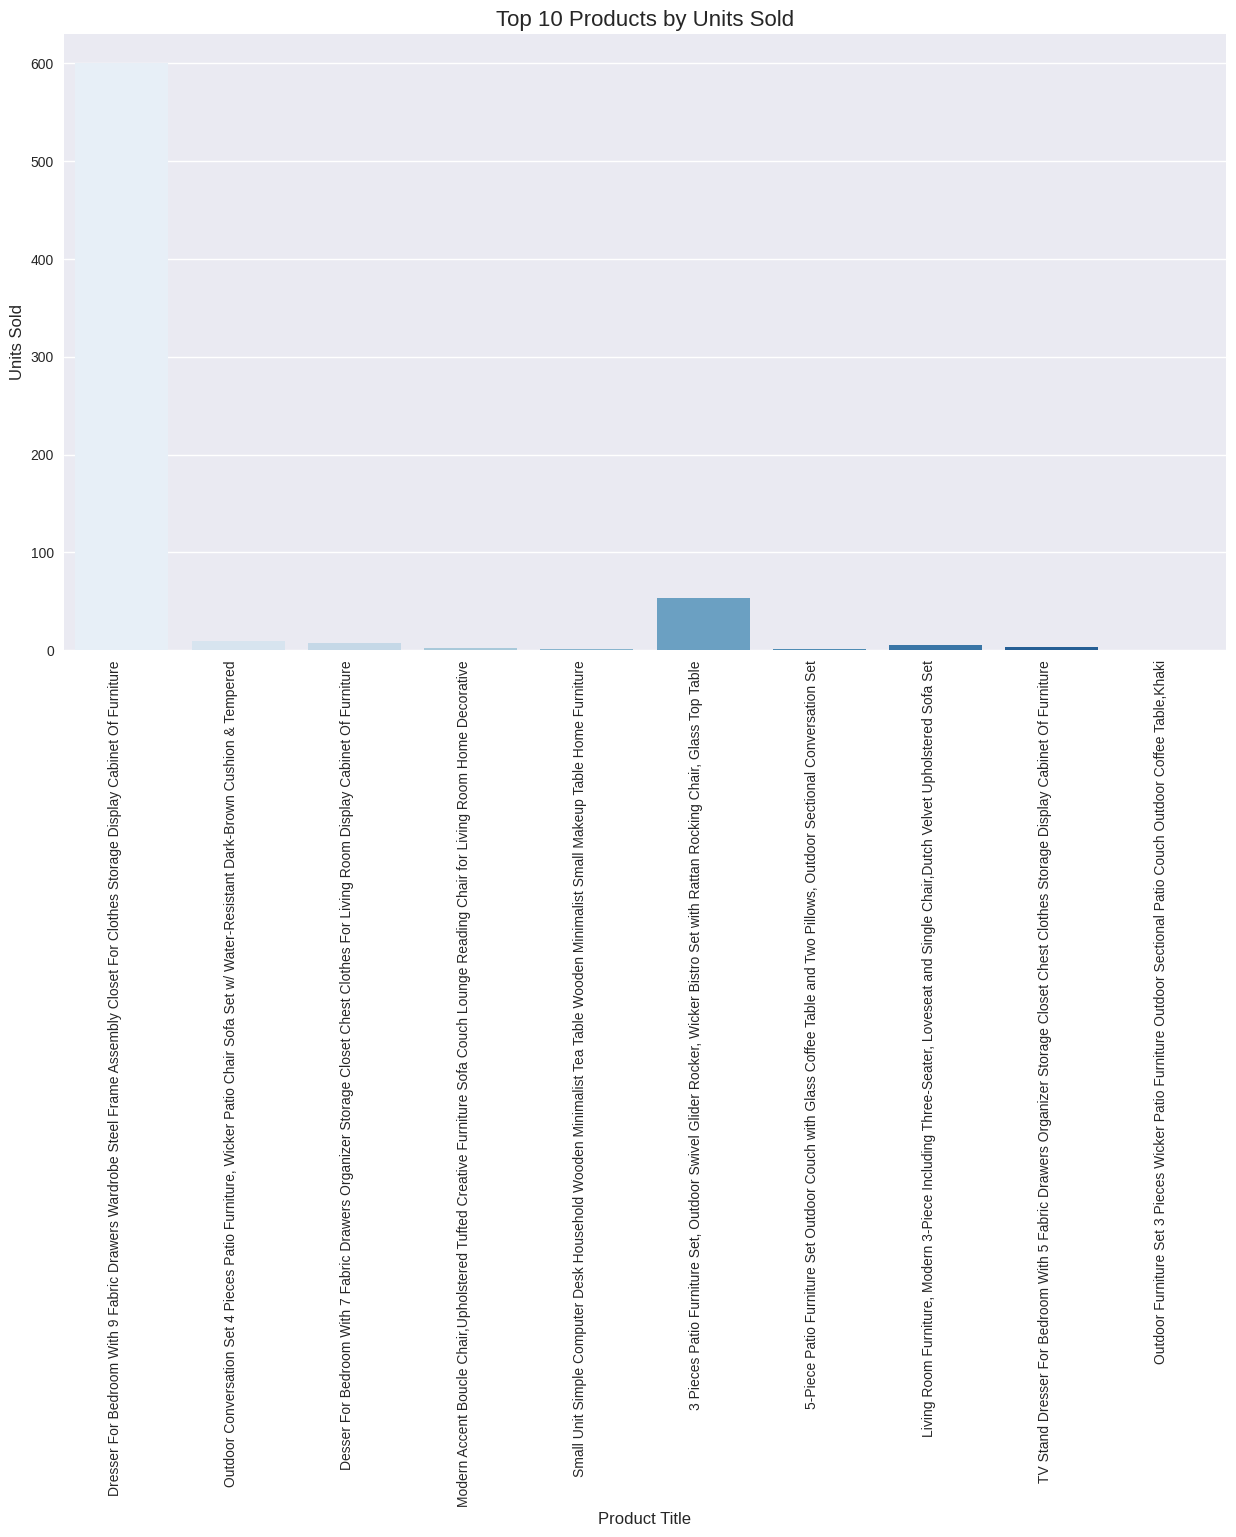

In [8]:
plt.figure(figsize=(15, 8)) # Increased figure size
sns.barplot(x='productTitle', y='sold', data=df.head(10), palette='Blues')
plt.title('Top 10 Products by Units Sold', fontsize=16) # Increased title fontsize
plt.xlabel('Product Title', fontsize=12) # Increased xlabel fontsize
plt.ylabel('Units Sold', fontsize=12) # Increased ylabel fontsize
plt.xticks(rotation=90, ha='right', fontsize=10) # Adjust label alignment and fontsize
plt.tight_layout(rect=[0, 0, 1, 0.9]) # Further adjust layout to prevent overlap
plt.show()

In [9]:

if 'Region' in df.columns:
    plt.figure(figsize=(8,5))
    sns.barplot(x='Region', y='Sales', data=df, ci=None, palette='viridis')
    plt.title('Sales by Region')
    plt.xticks(rotation=45)
    plt.show()


In [10]:

if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Month'] = df['Order Date'].dt.month

    monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

    plt.figure(figsize=(8,5))
    sns.lineplot(x='Month', y='Sales', data=monthly_sales, marker='o', color='purple')
    plt.title('Monthly Sales Trend')
    plt.show()


In [11]:

if 'Product Name' in df.columns:
    top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_products.values, y=top_products.index, palette='cool')
    plt.title('Top 10 Selling Products')
    plt.xlabel('Total Sales')
    plt.ylabel('Product Name')
    plt.show()


## Step 6: Simple Predictive Model (Optional)

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

features = ['Quantity', 'Discount', 'Profit']
target = 'Sales'

if all(col in df.columns for col in features+[target]):
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"\nModel RMSE: {rmse:.2f}")


## Step 7: Insights Summary

In [13]:

print("✅ Project Summary:")
print("- Cleaned and explored furniture sales dataset.")
print("- Visualized sales trends by category, month, and top products.")
print("- Built a simple Random Forest model to predict future sales.")
print("- Gained insights into which categories and products drive revenue.")


✅ Project Summary:
- Cleaned and explored furniture sales dataset.
- Visualized sales trends by category, month, and top products.
- Built a simple Random Forest model to predict future sales.
- Gained insights into which categories and products drive revenue.
